In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Eda

## Finding some good stuff

In [102]:
df = pd.read_csv('ai_worker_burnout_attrition_2026.csv')
df

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,EMP1496,Frontend Engineer,2,Master,Brazil,Fintech,Enterprise (5000+),Hybrid,36,47,...,7,6.9,69,Integrating,2.6,74,63,3.1,High,Medium
1496,EMP1497,Prompt Engineer,1,PhD,UK,E-commerce,Small (50-200),Hybrid,22,199,...,1,1.2,7,Integrating,6.9,39,25,3.5,Low,Low
1497,EMP1498,Backend Engineer,8,Bachelor,Canada,Cybersecurity,Mid (200-1000),Hybrid,48,120,...,3,6.8,73,Optimizing,4.0,44,65,2.9,High,High
1498,EMP1499,AI Ethics Officer,13,Self-taught,Netherlands,Media,Startup (<50),Fully Remote,41,208,...,6,3.2,68,Optimizing,4.1,77,53,2.8,Low,Medium


In [103]:
df['company_size'].value_counts()

company_size
Mid (200-1000)        317
Enterprise (5000+)    312
Startup (<50)         311
Large (1000-5000)     286
Small (50-200)        274
Name: count, dtype: int64

In [104]:
df['job_role'].unique()

array(['Data Analyst', 'DevOps Engineer', 'Prompt Engineer',
       'Backend Engineer', 'AI Researcher', 'AI Ethics Officer',
       'Data Scientist', 'Product Manager', 'ML Engineer',
       'Cloud Architect', 'Software Engineer', 'Frontend Engineer'],
      dtype=object)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   object 
 1   job_role                        1500 non-null   object 
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   object 
 4   country                         1500 non-null   object 
 5   industry                        1500 non-null   object 
 6   company_size                    1500 non-null   object 
 7   remote_work_type                1500 non-null   object 
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   object 
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  15

In [106]:
df.isna().sum()

employee_id                       0
job_role                          0
years_experience                  0
education_level                   0
country                           0
industry                          0
company_size                      0
remote_work_type                  0
team_size                         0
salary_usd_k                      0
primary_ai_tool                   0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
ai_adoption_stage                 0
weekly_ai_upskilling_hrs          0
productivity_score                0
burnout_score                     0
job_satisfaction_1_5              0
fear_of_ai_replacement            0
attrition_risk                    0
dtype: int64

In [107]:
df.duplicated().sum()

0

In [108]:
df.describe()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5
count,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.05600,4.233733,41.248667,4.985533,57.543333,50.057333,3.334733
std,5.460932,13.682582,59.717429,1.97403,2.148387,21.658214,2.913933,10.726952,11.437771,0.636692
min,1.000000,2.000000,40.000000,1.00000,0.500000,5.000000,0.000000,25.000000,16.000000,1.300000
25%,5.000000,13.000000,91.000000,2.00000,2.400000,22.750000,2.400000,50.000000,42.000000,2.900000
50%,10.000000,25.000000,139.000000,4.00000,4.200000,40.000000,5.000000,57.000000,50.000000,3.300000
75%,15.000000,36.000000,190.000000,6.00000,6.100000,60.000000,7.500000,65.000000,58.000000,3.800000
max,19.000000,49.000000,249.000000,7.00000,8.000000,79.000000,10.000000,95.000000,86.000000,5.000000


In [109]:
df['job_satisfaction_1_5'].describe()

count    1500.000000
mean        3.334733
std         0.636692
min         1.300000
25%         2.900000
50%         3.300000
75%         3.800000
max         5.000000
Name: job_satisfaction_1_5, dtype: float64

In [110]:
interval = (df['job_satisfaction_1_5'].max() - df['job_satisfaction_1_5'].min())/3
interval

1.2333333333333334

In [111]:
low_max_inter = df['job_satisfaction_1_5'].min() +  interval
med_max_inter = low_max_inter + interval
high_max_inter = med_max_inter + interval

low = [0, low_max_inter]
medium = [low_max_inter, med_max_inter]
high = [med_max_inter, high_max_inter]

print('low: ',low)
print('medium: ',medium)
print('high: ',high)

low:  [0, 2.533333333333333]
medium:  [2.533333333333333, 3.7666666666666666]
high:  [3.7666666666666666, 5.0]


In [112]:
bins = [0, low_max_inter, med_max_inter, high_max_inter]
kelas = ['Low', 'Medium/Neutral', 'High']

In [113]:
df['job_satisfaction_category'] = pd.cut(df['job_satisfaction_1_5'], bins=bins, labels=kelas)

In [114]:
df[['job_satisfaction_1_5','job_satisfaction_category']]

,job_satisfaction_1_5,job_satisfaction_category
0,3.0,Medium/Neutral
1,3.6,Medium/Neutral
2,4.6,High
3,3.0,Medium/Neutral
4,3.6,Medium/Neutral
...,...,...
1495,3.1,Medium/Neutral
1496,3.5,Medium/Neutral
1497,2.9,Medium/Neutral
1498,2.8,Medium/Neutral


In [115]:
df['job_satisfaction_category'].value_counts()

job_satisfaction_category
Medium/Neutral    934
High              401
Low               165
Name: count, dtype: int64

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   employee_id                     1500 non-null   object  
 1   job_role                        1500 non-null   object  
 2   years_experience                1500 non-null   int64   
 3   education_level                 1500 non-null   object  
 4   country                         1500 non-null   object  
 5   industry                        1500 non-null   object  
 6   company_size                    1500 non-null   object  
 7   remote_work_type                1500 non-null   object  
 8   team_size                       1500 non-null   int64   
 9   salary_usd_k                    1500 non-null   int64   
 10  primary_ai_tool                 1500 non-null   object  
 11  ai_tools_used_per_day           1500 non-null   int64   
 12  hours_with_ai_assist

In [117]:
df.value_counts(['ai_adoption_stage','job_satisfaction_category']).unstack()

job_satisfaction_category,Low,Medium/Neutral,High
ai_adoption_stage,,,
AI-First,29,153,68
Experimenting,41,221,96
Integrating,52,309,131
Optimizing,43,251,106


In [118]:
table = df.value_counts(['ai_adoption_stage','job_satisfaction_category']).unstack()
percent_table = (table.div(table.sum(axis=1), axis=0) * 100).round(2)
percent_table

job_satisfaction_category,Low,Medium/Neutral,High
ai_adoption_stage,,,
AI-First,11.60,61.20,27.20
Experimenting,11.45,61.73,26.82
Integrating,10.57,62.80,26.63
Optimizing,10.75,62.75,26.50


In [119]:
df.groupby('job_satisfaction_category')[[
    'salary_usd_k',
    'years_experience',
    'ai_tools_used_per_day',
    'hours_with_ai_assistance_daily',
    'ai_replaces_my_tasks_pct',
    'weekly_ai_upskilling_hrs',
    'productivity_score',
    'burnout_score'
]].mean()

/tmp/ipykernel_70935/4261787977.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('job_satisfaction_category')[[


,salary_usd_k,years_experience,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,burnout_score
job_satisfaction_category,,,,,,,,
Low,144.793939,10.230303,3.872727,5.096970,57.224242,5.069697,57.430303,62.727273
Medium/Neutral,140.148822,9.794433,4.049251,4.359743,42.483940,5.039615,57.573876,51.423983
High,140.426434,10.187032,4.147132,3.585037,31.798005,4.824938,57.518703,41.660848


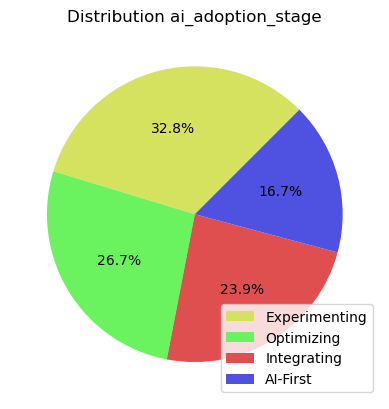

In [120]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f", "#4f51e0"]

label = df["ai_adoption_stage"].unique()
size = df["ai_adoption_stage"].value_counts()

plt.pie(size, autopct="%1.1f%%", startangle=45, colors=custom_colors)
plt.title("Distribution ai_adoption_stage")
plt.legend(label)

/tmp/ipykernel_70935/3962348766.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='hours_with_ai_assistance_daily', data=df, palette=custom_colors, errorbar=None)


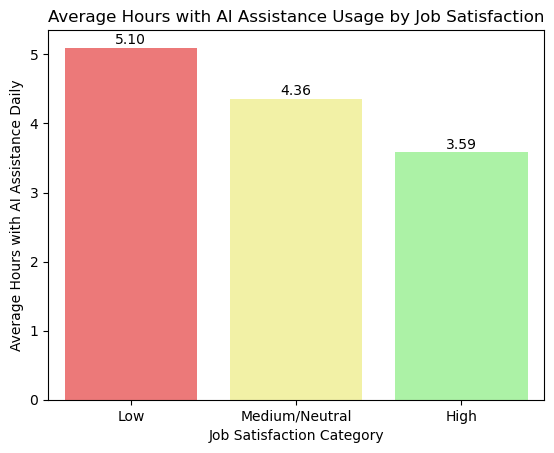

In [121]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='hours_with_ai_assistance_daily', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Hours with AI Assistance Usage by Job Satisfaction")
plt.show()


In [122]:
df['fear_of_ai_replacement'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

/tmp/ipykernel_70935/3736758761.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


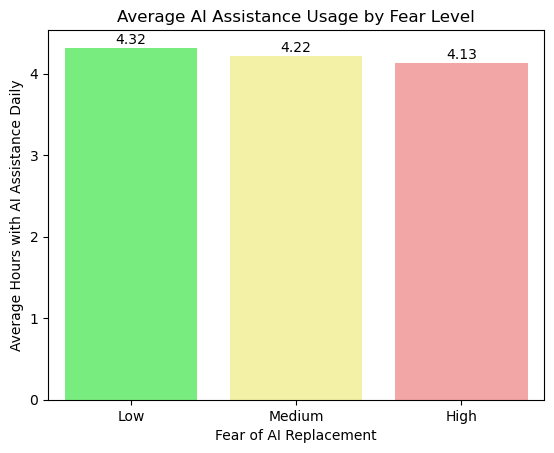

In [123]:
custom_colors = ["#66ff6e", "#fffd99", "#ff9999"]
ax = sns.barplot(
    x='fear_of_ai_replacement',
    y='hours_with_ai_assistance_daily',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("Fear of AI Replacement")
plt.title("Average AI Assistance Usage by Fear Level")
plt.show()

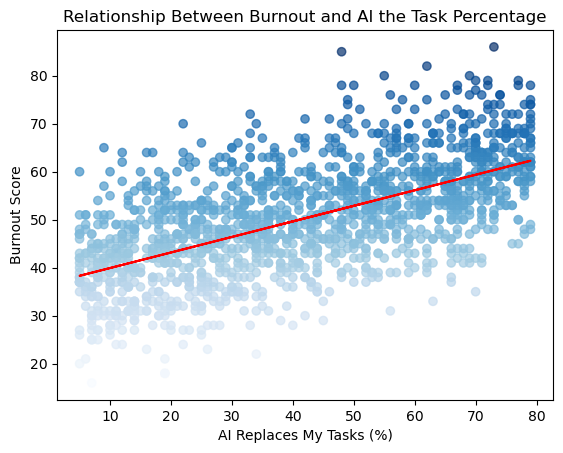

In [124]:
import numpy as np
y = df['burnout_score']
x = df['ai_replaces_my_tasks_pct']

plt.scatter(x, y, c=y, cmap='Blues', alpha=0.7)

# membuat garis regresi linear
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

# label sumbu
plt.ylabel("Burnout Score")
plt.xlabel("AI Replaces My Tasks (%)")

# judul (opsional)
plt.title("Relationship Between Burnout and AI the Task Percentage")

plt.show()

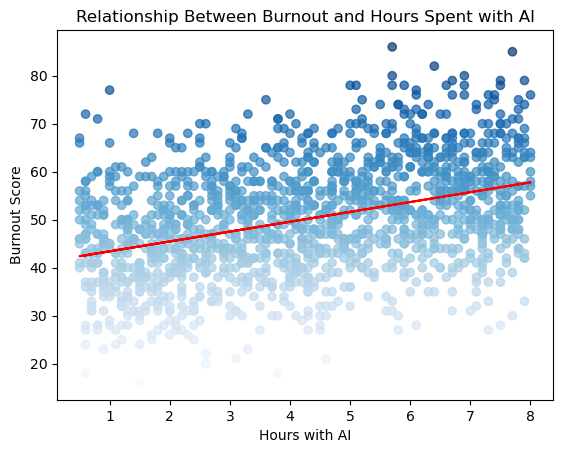

In [125]:
y = df['burnout_score']
x = df['hours_with_ai_assistance_daily']

plt.scatter(x, y, c=y, cmap='Blues', alpha=0.7)

# membuat garis regresi linear
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

# label sumbu
plt.ylabel("Burnout Score")
plt.xlabel("Hours with AI")

# judul (opsional)
plt.title("Relationship Between Burnout and Hours Spent with AI")

plt.show()

In [126]:
df['education_level'].unique()

array(['PhD', 'Self-taught', 'Master', 'Bachelor', 'Bootcamp'],
      dtype=object)

/tmp/ipykernel_70935/311812148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


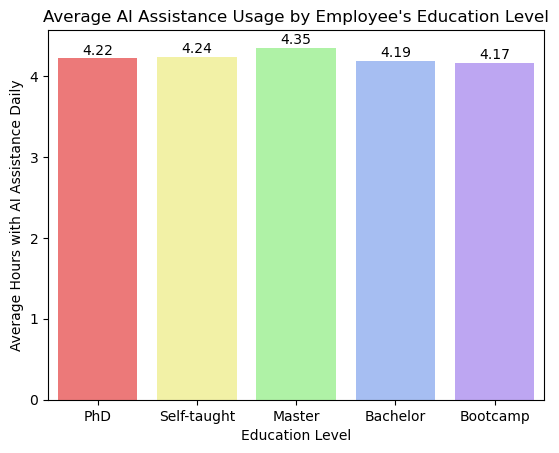

In [127]:
custom_colors = ["#ff6666", "#fffd99", "#a5ff99", "#99b9ff", "#b899ff"]
ax = sns.barplot(
    x='education_level',
    y='hours_with_ai_assistance_daily',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("Education Level")
plt.title("Average AI Assistance Usage by Employee's Education Level")
plt.show()

/tmp/ipykernel_70935/389923524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


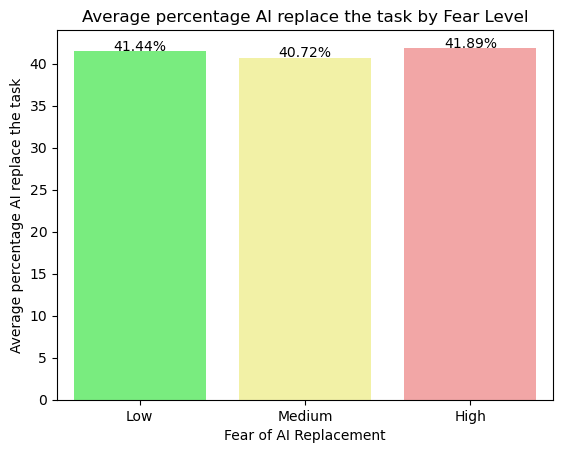

In [128]:
custom_colors = ["#66ff6e", "#fffd99", "#ff9999"]
ax = sns.barplot(
    x='fear_of_ai_replacement',
    y='ai_replaces_my_tasks_pct',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}%",
        ha='center'
    )

plt.ylabel("Average percentage AI replace the task")
plt.xlabel("Fear of AI Replacement")
plt.title("Average percentage AI replace the task by Fear Level")
plt.show()

/tmp/ipykernel_70935/3727660582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


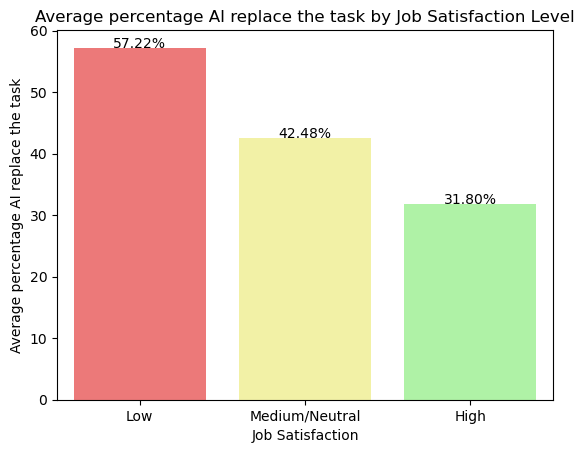

In [129]:
custom_colors = ["#ff6666", "#fffd99", "#a5ff99"]
ax = sns.barplot(
    x='job_satisfaction_category',
    y='ai_replaces_my_tasks_pct',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}%",
        ha='center'
    )

plt.ylabel("Average percentage AI replace the task")
plt.xlabel("Job Satisfaction")
plt.title("Average percentage AI replace the task by Job Satisfaction Level")
plt.show()

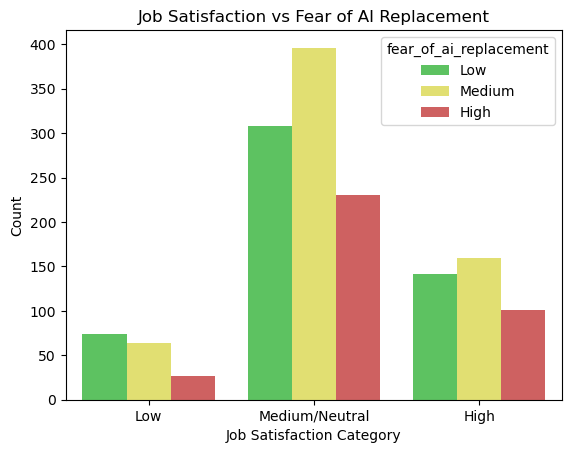

In [130]:
custom_colors = ["#4cd352", "#f3f15f", "#e04f4f"]

sns.countplot(
    x='job_satisfaction_category',
    hue='fear_of_ai_replacement',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Fear of AI Replacement")
plt.xlabel("Job Satisfaction Category")
plt.ylabel("Count")
plt.show()

In [131]:
df['attrition_risk'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

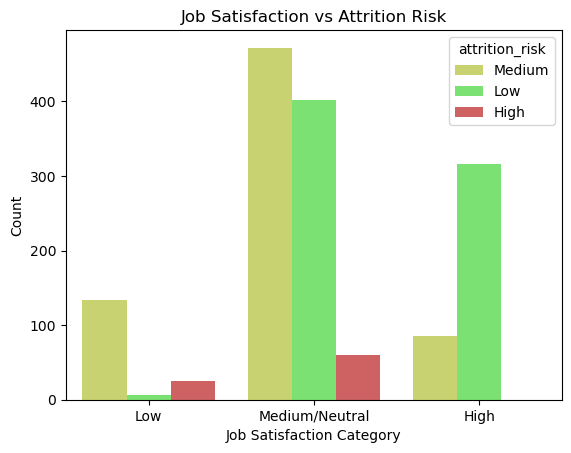

In [132]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]

sns.countplot(
    x='job_satisfaction_category',
    hue='attrition_risk',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Attrition Risk")
plt.xlabel("Job Satisfaction Category")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_70935/2857771013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='burnout_score', data=df, palette=custom_colors, errorbar=None)


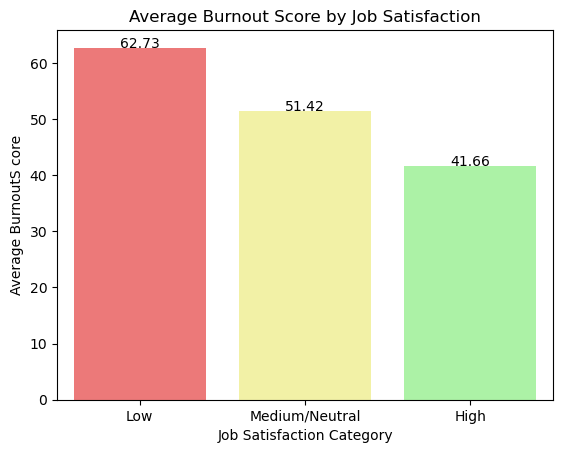

In [133]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='burnout_score', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average BurnoutS core")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Burnout Score by Job Satisfaction")
plt.show()


/tmp/ipykernel_70935/3826507753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='attrition_risk', y='burnout_score', data=df, palette=custom_colors, errorbar=None)


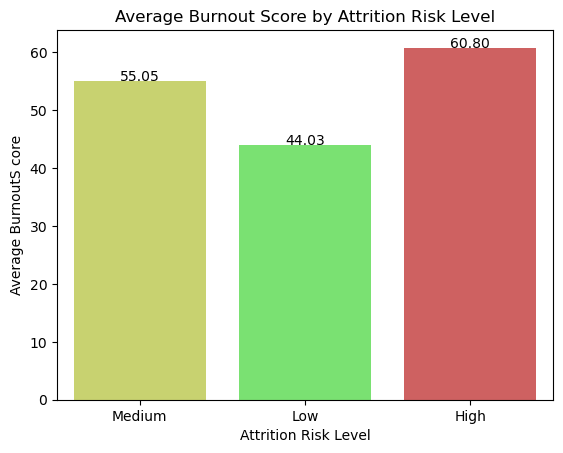

In [134]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]
ax = sns.barplot(x='attrition_risk', y='burnout_score', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average BurnoutS core")
plt.xlabel("Attrition Risk Level")
plt.title("Average Burnout Score by Attrition Risk Level")
plt.show()


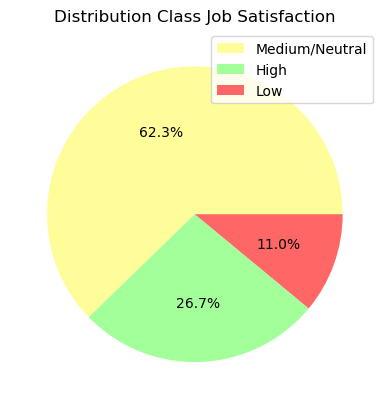

In [135]:
custom_colors = ["#fffd99","#a2ff99", "#ff6666"]

label = df["job_satisfaction_category"].unique()
size = df["job_satisfaction_category"].value_counts()

plt.pie(size, autopct="%1.1f%%", colors=custom_colors)
plt.title("Distribution Class Job Satisfaction")
plt.legend(label)

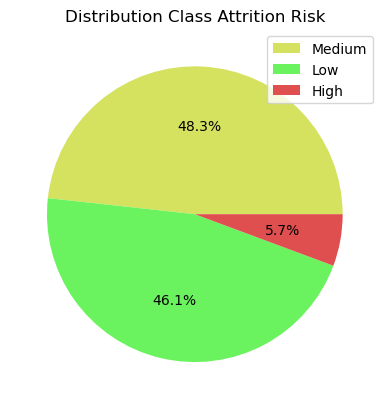

In [136]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]

label = df["attrition_risk"].unique()
size = df["attrition_risk"].value_counts()

plt.pie(size, autopct="%1.1f%%", colors=custom_colors)
plt.title("Distribution Class Attrition Risk")
plt.legend(label)

/tmp/ipykernel_70935/2457328889.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None)


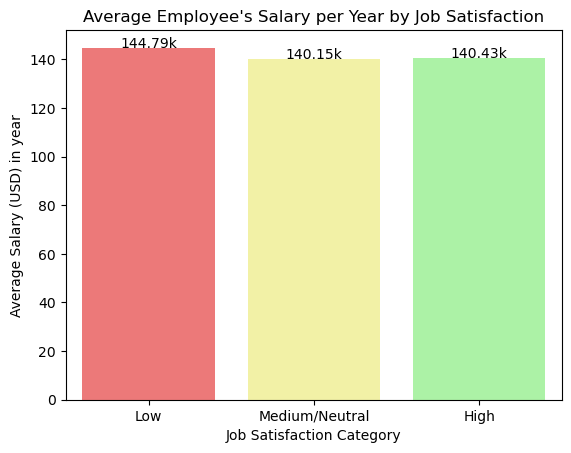

In [137]:

custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}k",
        ha='center'
    )

plt.ylabel("Average Salary (USD) in year")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Employee's Salary per Year by Job Satisfaction")
plt.show()


/tmp/ipykernel_70935/553149449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='attrition_risk', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None)


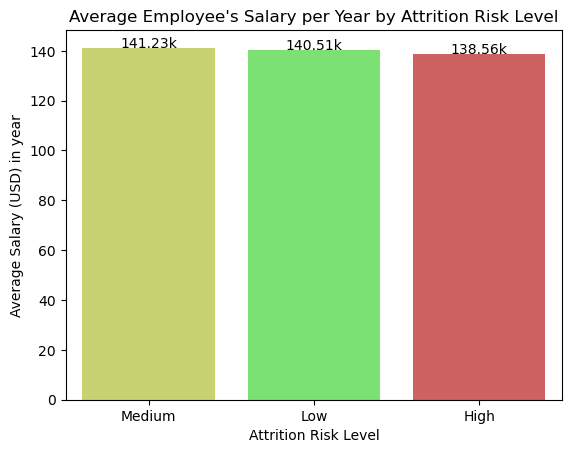

In [138]:

custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]
ax = sns.barplot(x='attrition_risk', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}k",
        ha='center'
    )

plt.ylabel("Average Salary (USD) in year")
plt.xlabel("Attrition Risk Level")
plt.title("Average Employee's Salary per Year by Attrition Risk Level")
plt.show()


/tmp/ipykernel_70935/1387032933.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='attrition_risk', y='years_experience', data=df, palette=custom_colors, errorbar=None)


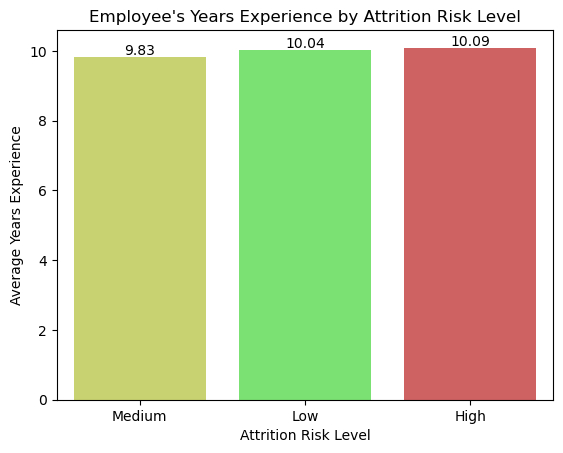

In [139]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f"]
ax = sns.barplot(x='attrition_risk', y='years_experience', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Years Experience")
plt.xlabel("Attrition Risk Level")
plt.title("Employee's Years Experience by Attrition Risk Level")
plt.show()


/tmp/ipykernel_70935/3919846008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='years_experience', data=df, palette=custom_colors, errorbar=None)


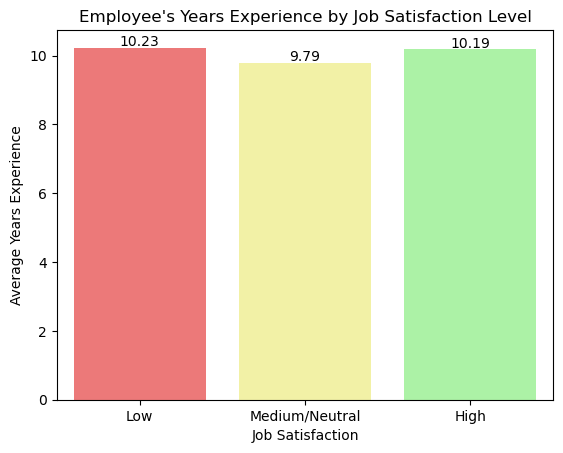

In [140]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='years_experience', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Years Experience")
plt.xlabel("Job Satisfaction")
plt.title("Employee's Years Experience by Job Satisfaction Level")
plt.show()


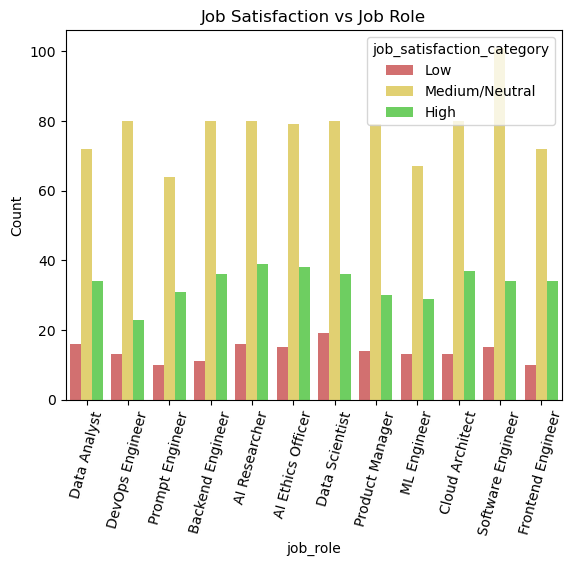

In [141]:
custom_colors = ["#e26060", "#f3dd5f", "#60e04f"]

sns.countplot(
    x='job_role',
    hue='job_satisfaction_category',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Job Role")
plt.xticks(rotation=75)
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_70935/1945066618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='ai_replaces_my_tasks_pct', y='job_role', data=df, palette="rocket", errorbar=None)


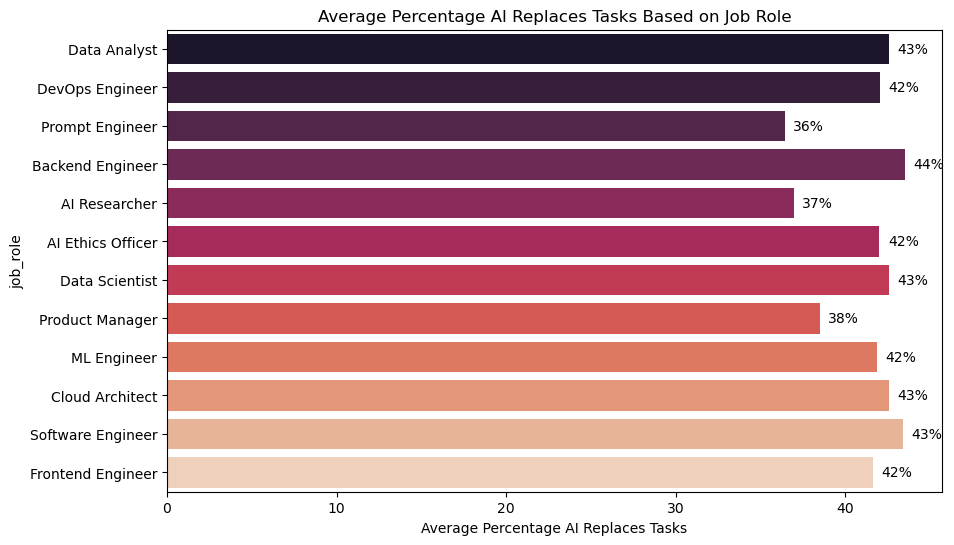

In [142]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x='ai_replaces_my_tasks_pct', y='job_role', data=df, palette="rocket", errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    # Untuk bar horizontal:
    # width = nilai (sumbu x)
    # y = posisi bar (sumbu y)
    width = p.get_width() 
    
    ax.text(
        width + 0.5,                # Posisi X: sedikit di kanan ujung bar
        p.get_y() + p.get_height()/2, # Posisi Y: tepat di tengah ketebalan bar
        f'{width:.0f}%',          # Format teks
        va='center'               # Alignment vertikal agar presisi di tengah
    )

plt.xlabel("Average Percentage AI Replaces Tasks")

plt.title("Average Percentage AI Replaces Tasks Based on Job Role")
plt.show()


/tmp/ipykernel_70935/2705096141.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='team_size', data=df, palette=custom_colors, errorbar=None)


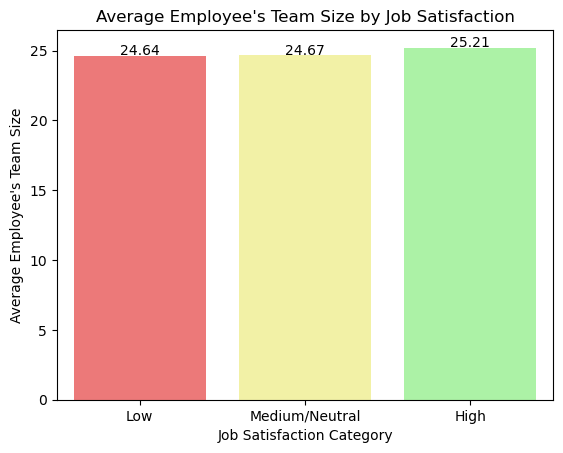

In [143]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='team_size', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Employee's Team Size")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Employee's Team Size by Job Satisfaction")
plt.show()


In [144]:
df['ai_adoption_stage'].unique()

array(['Experimenting', 'Optimizing', 'Integrating', 'AI-First'],
      dtype=object)

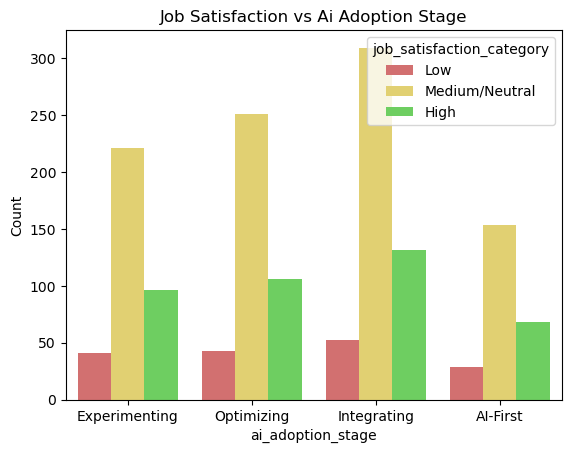

In [145]:
custom_colors = ["#e26060", "#f3dd5f", "#60e04f"]

sns.countplot(
    x='ai_adoption_stage',
    hue='job_satisfaction_category',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Ai Adoption Stage")
plt.ylabel("Count")
plt.show()

In [146]:
df['ai_adoption_stage'].value_counts()

ai_adoption_stage
Integrating      492
Optimizing       400
Experimenting    358
AI-First         250
Name: count, dtype: int64

In [147]:
df.groupby('ai_adoption_stage').agg(mean=('hours_with_ai_assistance_daily', 'mean'))

,mean
ai_adoption_stage,
AI-First,4.277600
Experimenting,4.181844
Integrating,4.221545
Optimizing,4.267750


/tmp/ipykernel_70935/1706807329.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='weekly_ai_upskilling_hrs', data=df, palette=custom_colors, errorbar=None)


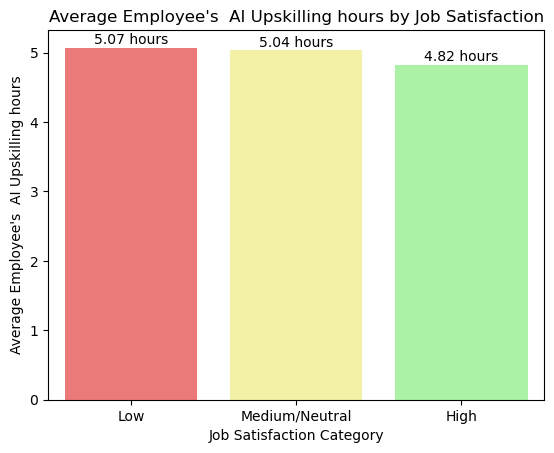

In [148]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='weekly_ai_upskilling_hrs', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f} hours",
        ha='center'
    )

plt.ylabel("Average Employee's  AI Upskilling hours")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Employee's  AI Upskilling hours by Job Satisfaction")
plt.show()


/tmp/ipykernel_70935/4170411931.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='productivity_score', data=df, palette=custom_colors, errorbar=None)


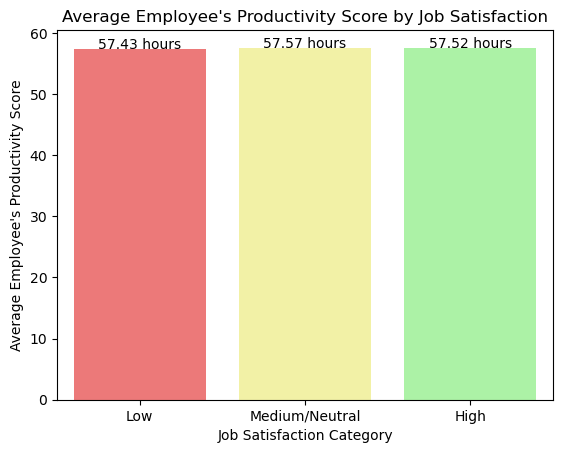

In [149]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='productivity_score', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f} hours",
        ha='center'
    )

plt.ylabel("Average Employee's Productivity Score")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Employee's Productivity Score by Job Satisfaction")
plt.show()


In [150]:
from scipy.stats import chi2_contingency


categorical_col = df.select_dtypes('object')
categorical_col.columns

Index(['employee_id', 'job_role', 'education_level', 'country', 'industry',
       'company_size', 'remote_work_type', 'primary_ai_tool',
       'ai_adoption_stage', 'fear_of_ai_replacement', 'attrition_risk'],
      dtype='object')

In [151]:
categorical_col = categorical_col.drop(columns='employee_id')

In [152]:
for col in categorical_col:
    contingency_table = pd.crosstab(df[col], df['job_satisfaction_category'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print('=========================')
    print(contingency_table)
    print()
    print(f"Chi-Square: {chi2}")
    print(f"P-Value: {p}")
    print('=========================')

job_satisfaction_category  Low  Medium/Neutral  High
job_role                                            
AI Ethics Officer           15              79    38
AI Researcher               16              80    39
Backend Engineer            11              80    36
Cloud Architect             13              80    37
Data Analyst                16              72    34
Data Scientist              19              80    36
DevOps Engineer             13              80    23
Frontend Engineer           10              72    34
ML Engineer                 13              67    29
Product Manager             14              79    30
Prompt Engineer             10              64    31
Software Engineer           15             101    34

Chi-Square: 10.489415606403414
P-Value: 0.981298170887069
job_satisfaction_category  Low  Medium/Neutral  High
education_level                                     
Bachelor                    27             193    94
Bootcamp                    33          

In [153]:
def calculate_cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    
    # Menghitung Cramer's V
    return np.sqrt(phi2 / min(r - 1, k - 1))

# Contoh penggunaan untuk 'attrition_risk' vs 'job_satisfaction_category'
table = pd.crosstab(df['attrition_risk'], df['job_satisfaction_category'])
v_score = calculate_cramers_v(table)

print(f"Cramer's V Score attrition_risk: {v_score:.4f}")

Cramer's V Score attrition_risk: 0.3177


In [154]:
table = pd.crosstab(df['fear_of_ai_replacement'], df['job_satisfaction_category'])
v_score = calculate_cramers_v(table)

print(f"Cramer's V Score fear_of_ai_replacement: {v_score:.4f}")

Cramer's V Score fear_of_ai_replacement: 0.0602


In [155]:
numerical_col = df.select_dtypes('number')
numerical_col.columns

Index(['years_experience', 'team_size', 'salary_usd_k',
       'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
       'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
       'productivity_score', 'burnout_score', 'job_satisfaction_1_5'],
      dtype='object')

<Axes: >

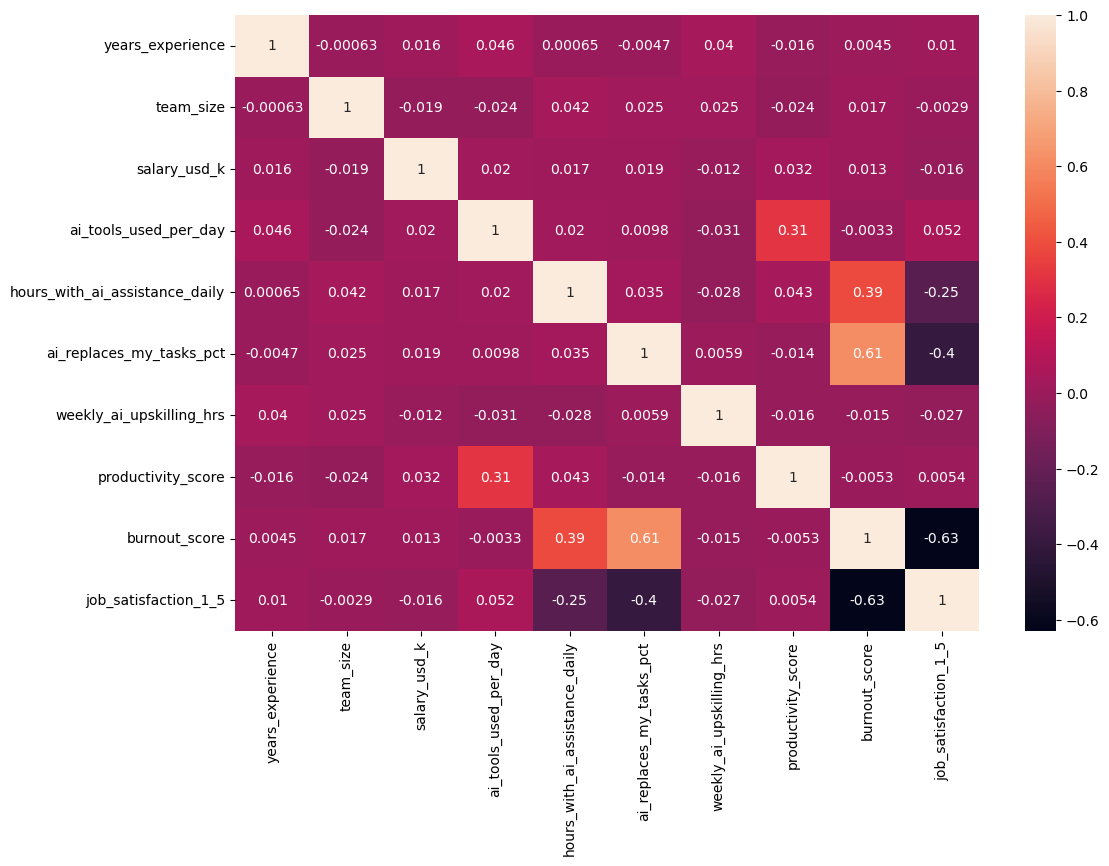

In [156]:
plt.figure(figsize=(12,8))
correlation = numerical_col.corr()
sns.heatmap(correlation, annot=True, cmap="rocket")


## Visualisasi variable yg berhubungan dengan job satisfaction

/tmp/ipykernel_70935/2408352659.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='hours_with_ai_assistance_daily', data=df, palette=custom_colors, errorbar=None)


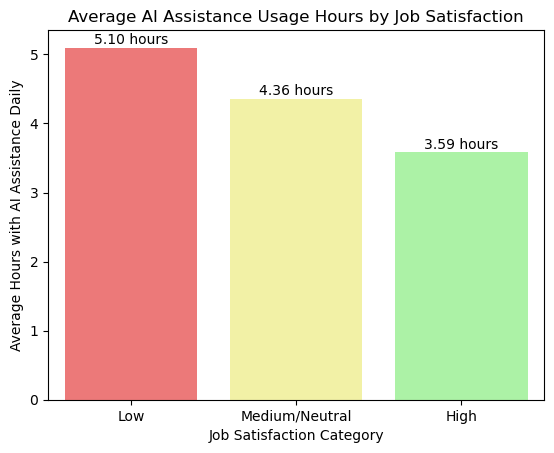

In [157]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='hours_with_ai_assistance_daily', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f} hours",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("Job Satisfaction Category")
plt.title("Average AI Assistance Usage Hours by Job Satisfaction")
plt.show()


/tmp/ipykernel_70935/3727660582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


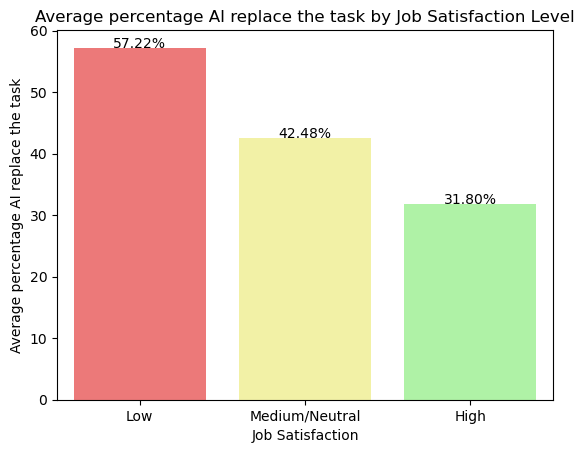

In [158]:
custom_colors = ["#ff6666", "#fffd99", "#a5ff99"]
ax = sns.barplot(
    x='job_satisfaction_category',
    y='ai_replaces_my_tasks_pct',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}%",
        ha='center'
    )

plt.ylabel("Average percentage AI replace the task")
plt.xlabel("Job Satisfaction")
plt.title("Average percentage AI replace the task by Job Satisfaction Level")
plt.show()

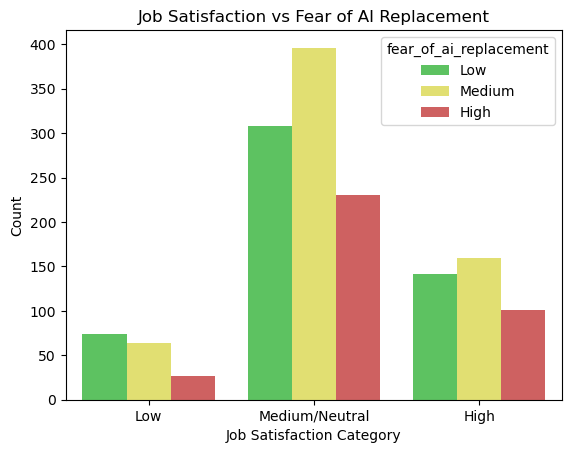

In [159]:
custom_colors = ["#4cd352", "#f3f15f", "#e04f4f"]

sns.countplot(
    x='job_satisfaction_category',
    hue='fear_of_ai_replacement',
    data=df,
    palette=custom_colors
)

plt.title("Job Satisfaction vs Fear of AI Replacement")
plt.xlabel("Job Satisfaction Category")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_70935/2857771013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='job_satisfaction_category', y='burnout_score', data=df, palette=custom_colors, errorbar=None)


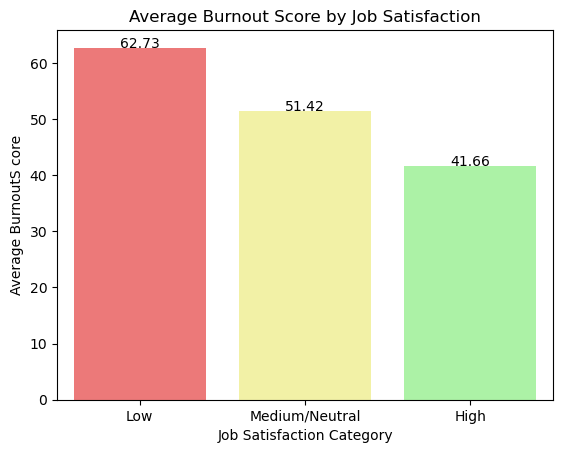

In [160]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='job_satisfaction_category', y='burnout_score', data=df, palette=custom_colors, errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average BurnoutS core")
plt.xlabel("Job Satisfaction Category")
plt.title("Average Burnout Score by Job Satisfaction")
plt.show()


## Check the BoxPlot for Each Numerical Col

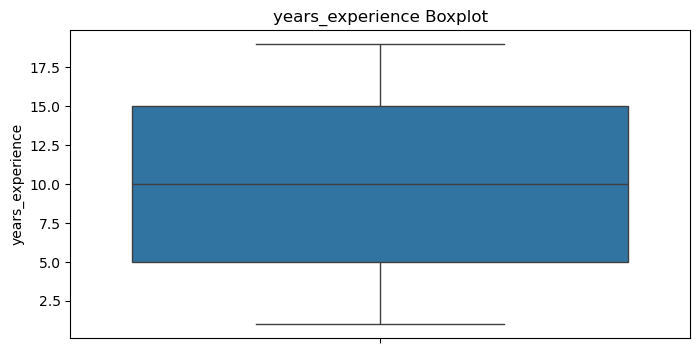

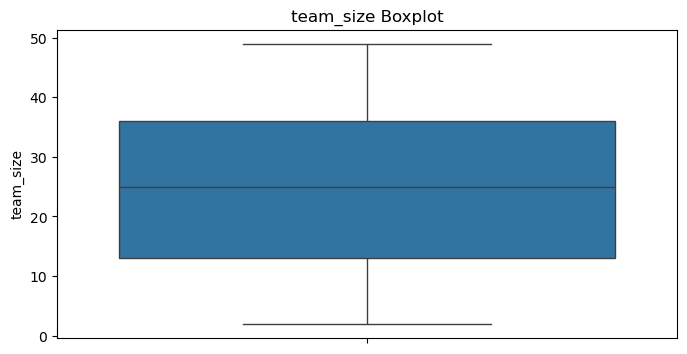

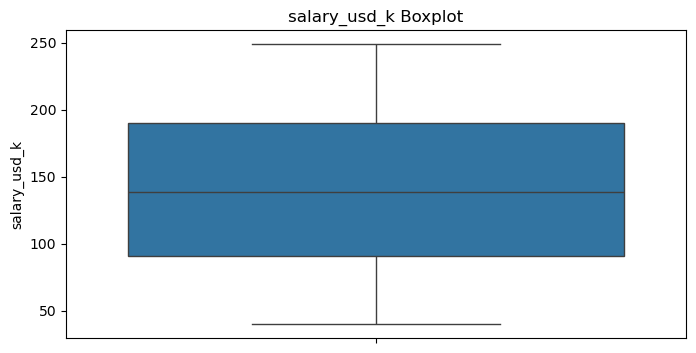

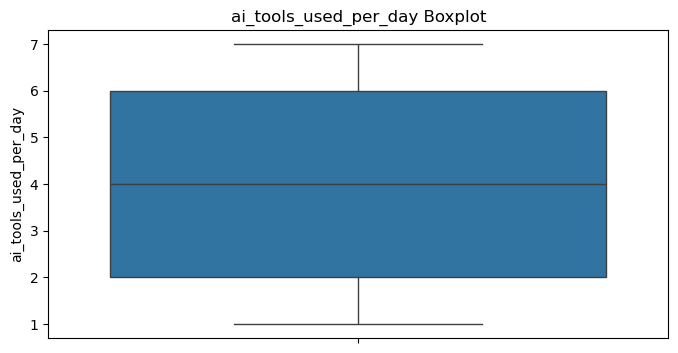

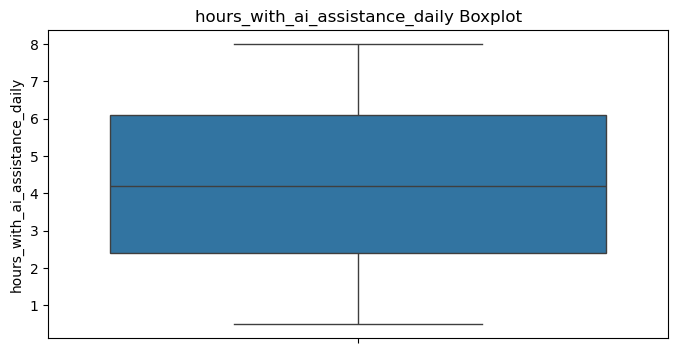

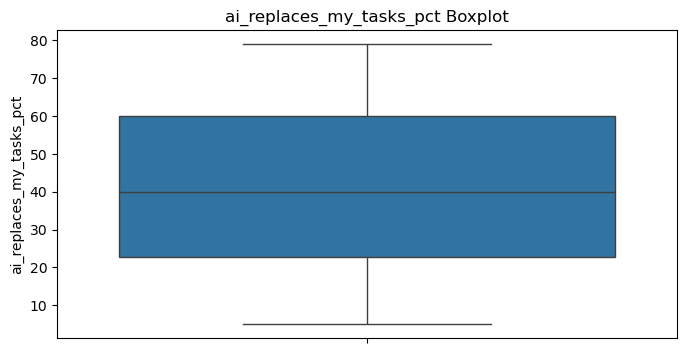

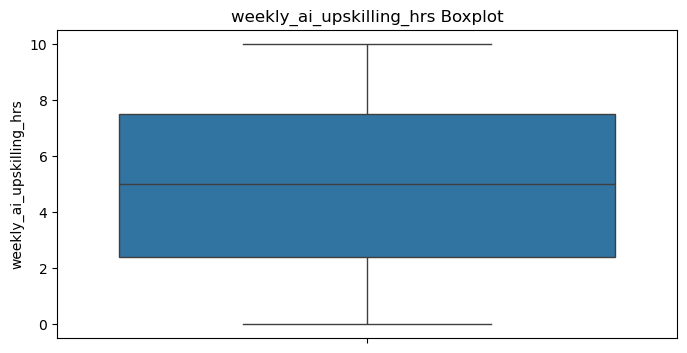

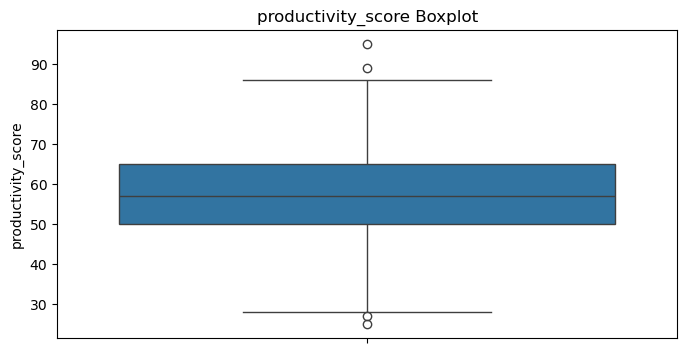

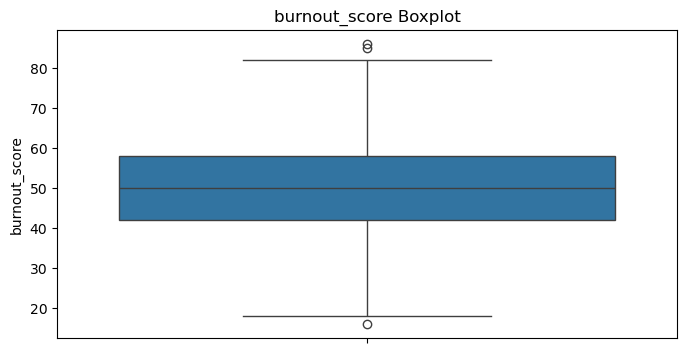

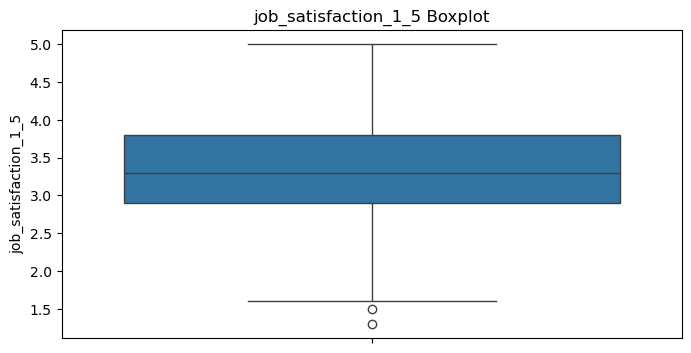

In [161]:
for col in numerical_col:
    plt.figure(figsize=(8,4))
    plt.title(f'{col} Boxplot')
    sns.boxplot(df[col])
    plt.show()


In [162]:
cat_cols = df.select_dtypes(include=['object','category'])
cat_cols = cat_cols.drop('employee_id', axis=1).columns


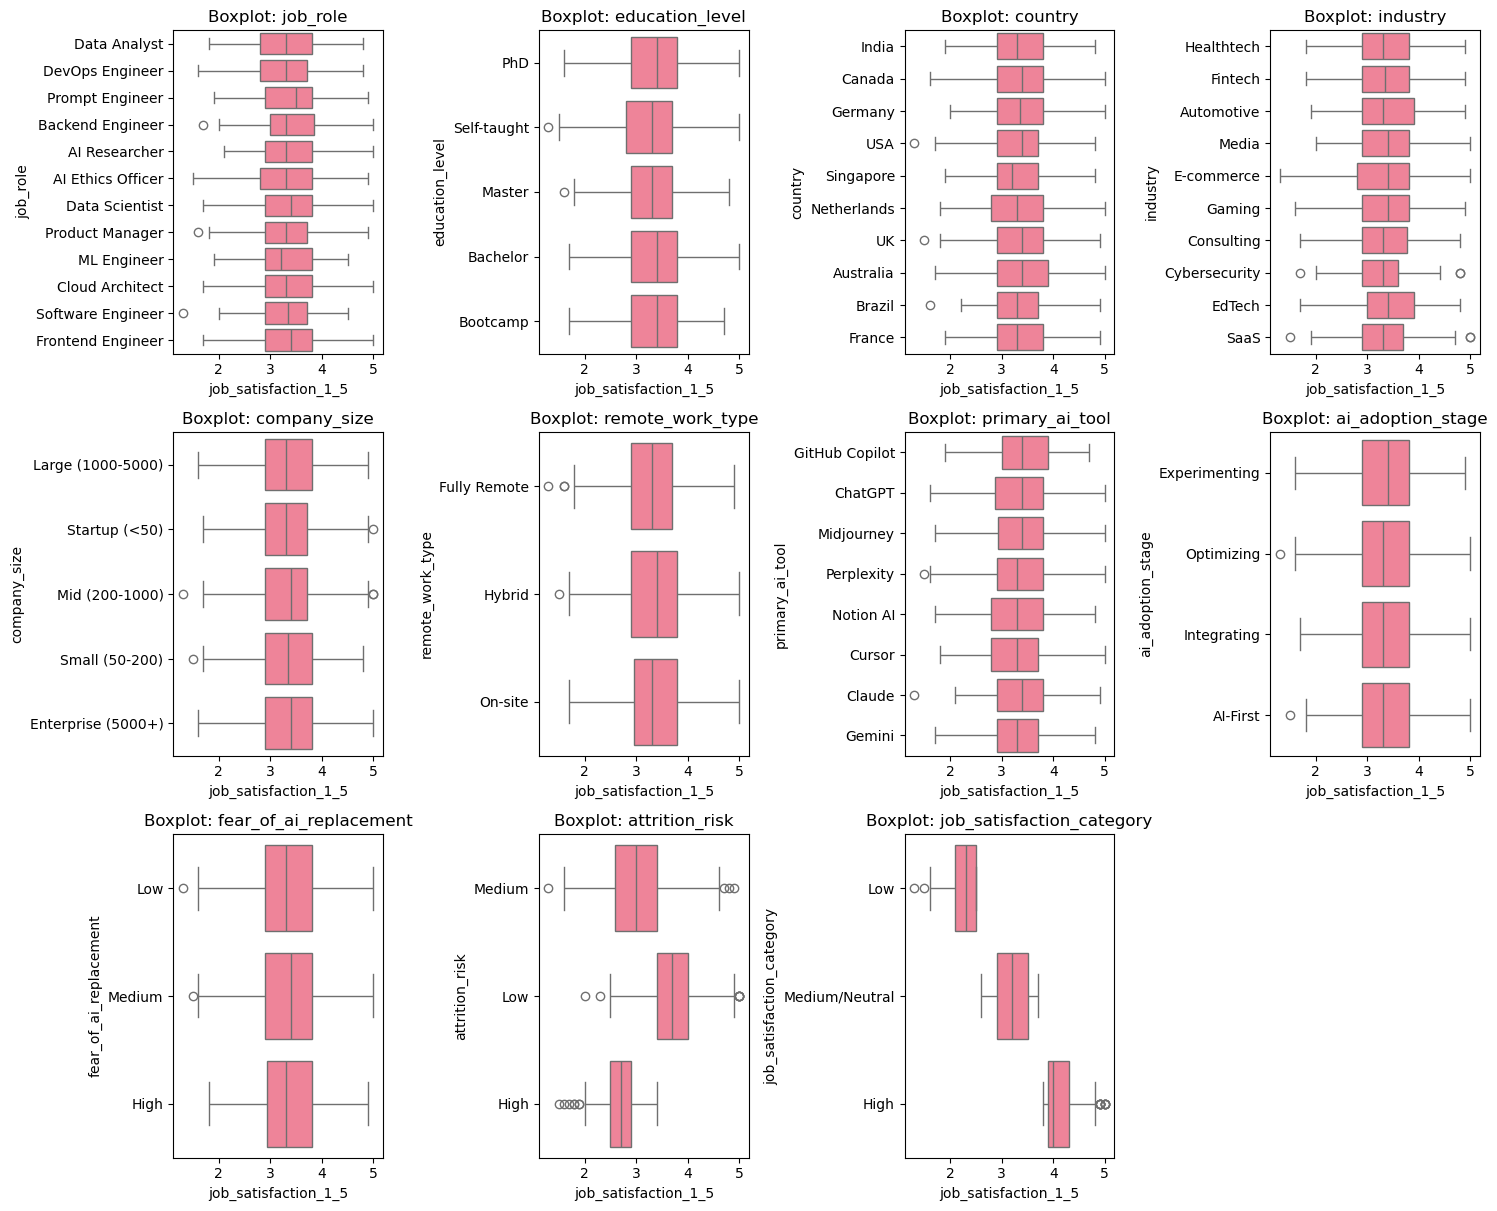

In [163]:
#Outlier

n_cols = 4
n_rows = (len(cat_cols) + n_cols - 1)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.boxplot(data=df, y=col, x="job_satisfaction_1_5", ax=axes[i], color="#FF738E")
    axes[i].set_title(f'Boxplot: {col}')
for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Check the distribution of the data

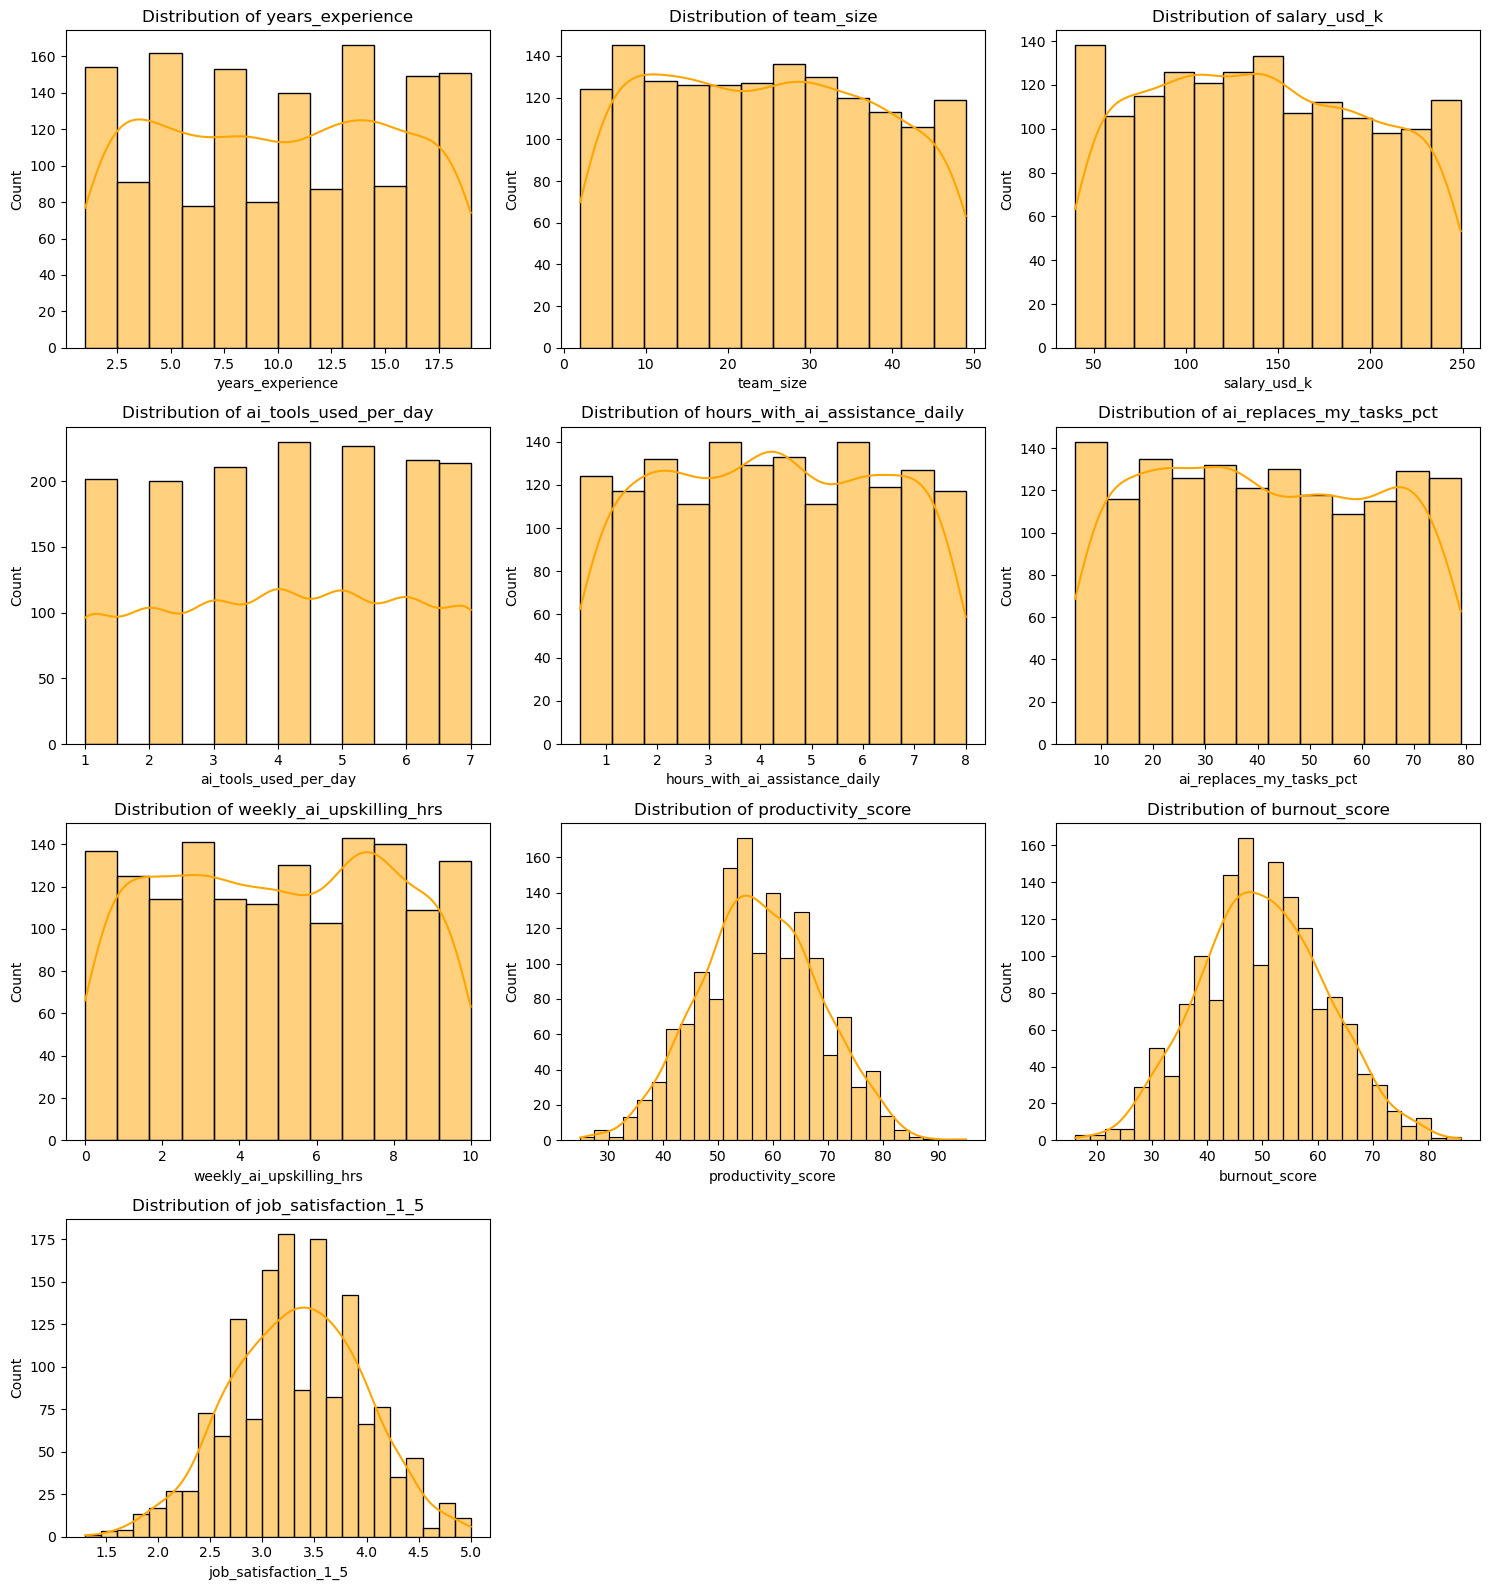

In [164]:
# pilih kolom numerik
num_cols = df.select_dtypes(include=['int64','float64']).columns

# ukuran subplot
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, color="orange")
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

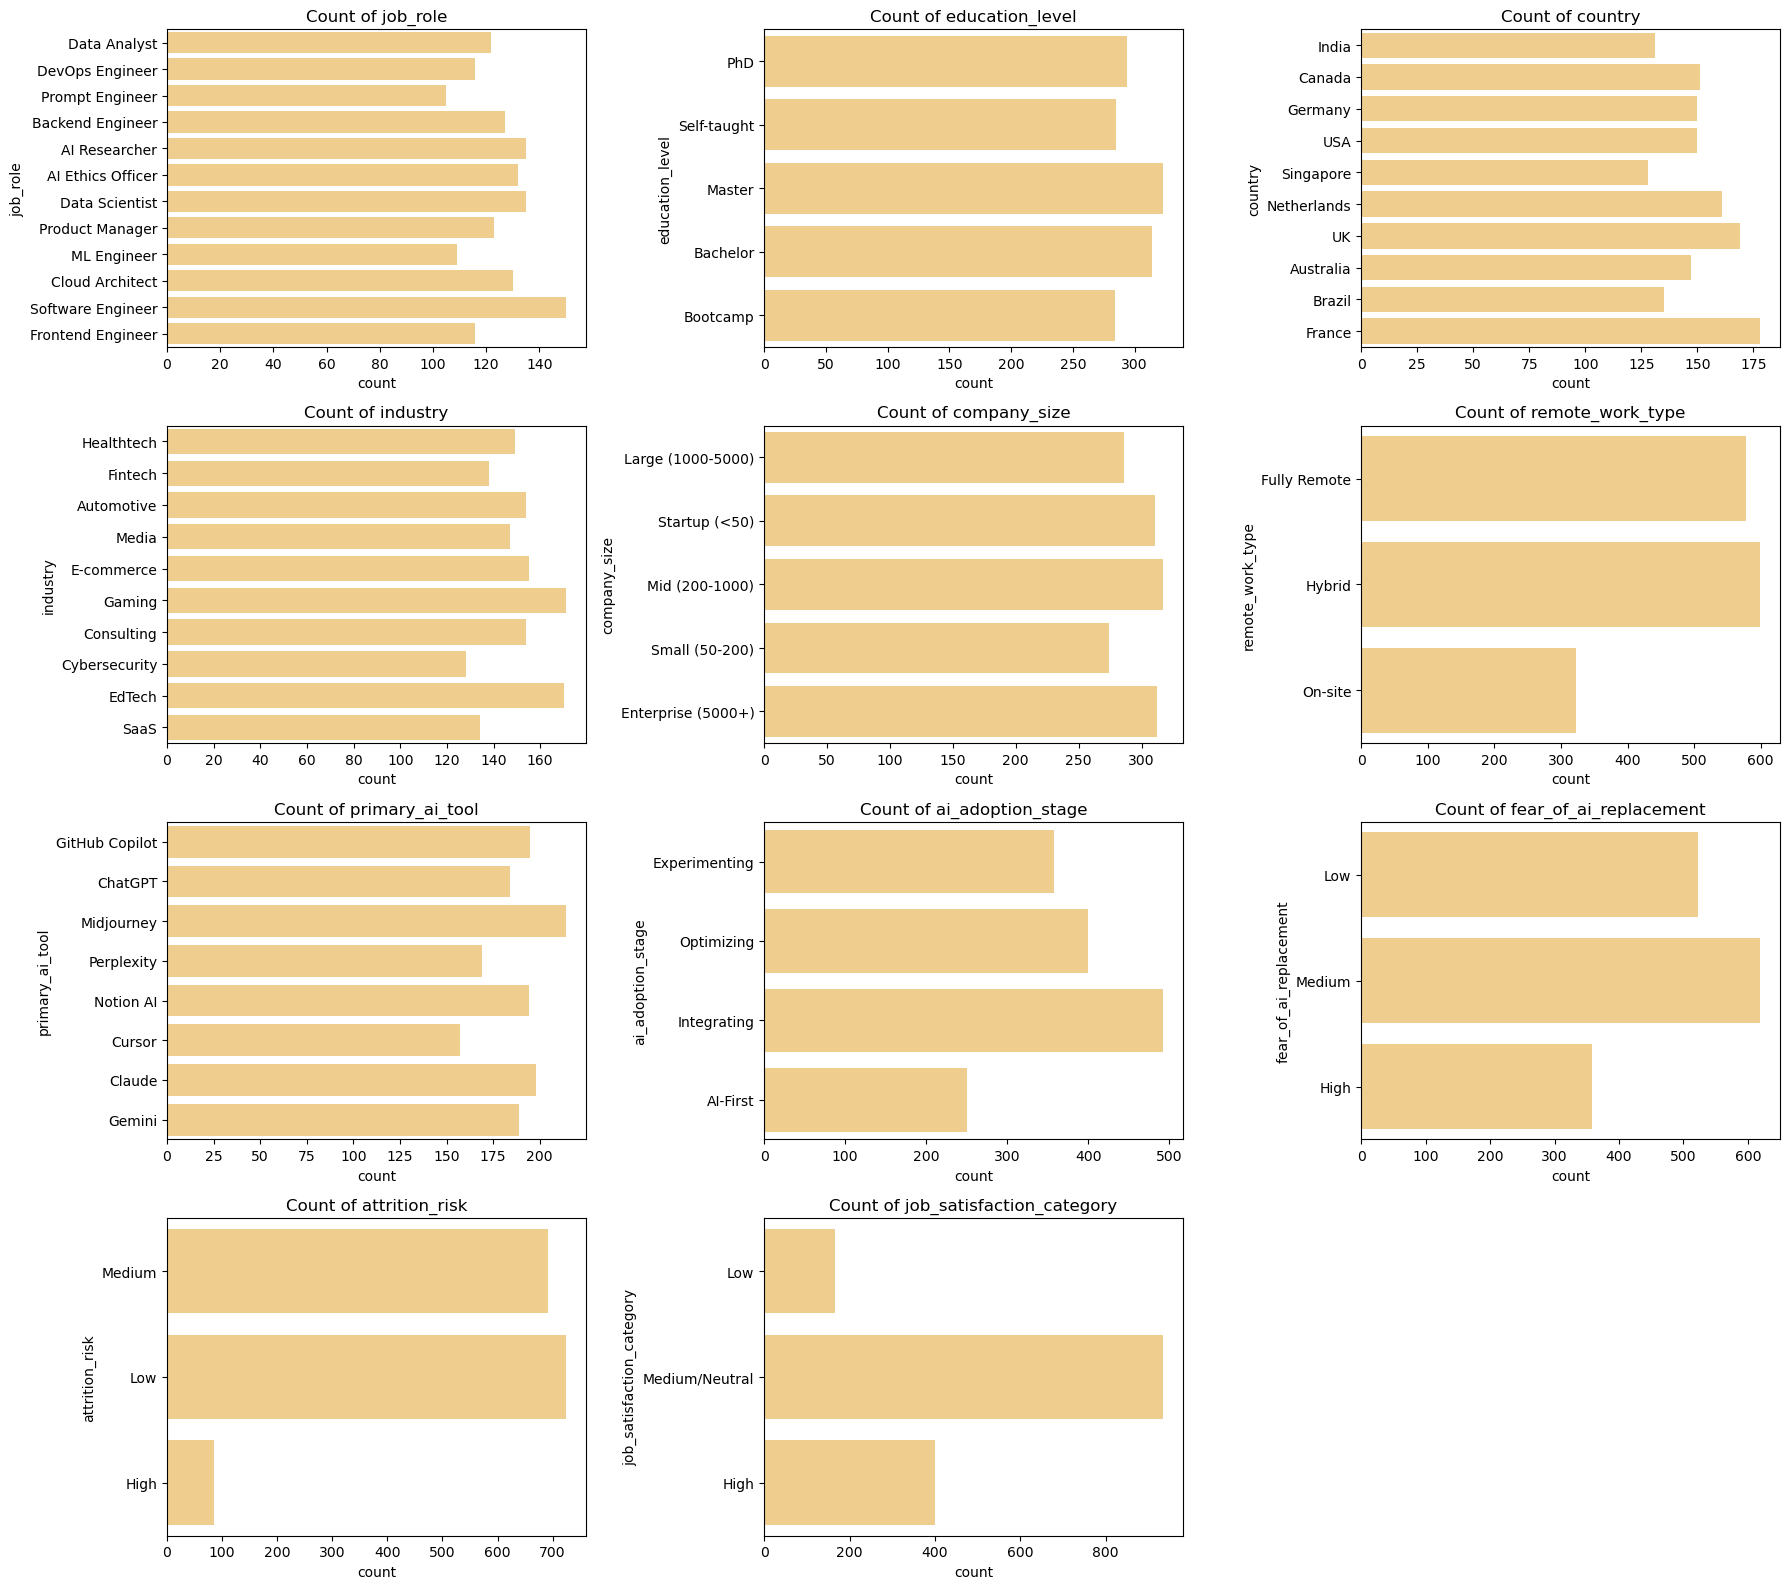

In [165]:
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, 4*n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, y=col, color="#FFD17F")
    plt.title(f'Count of {col}')

plt.tight_layout()
plt.show()

# Data preprocessing

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   employee_id                     1500 non-null   object  
 1   job_role                        1500 non-null   object  
 2   years_experience                1500 non-null   int64   
 3   education_level                 1500 non-null   object  
 4   country                         1500 non-null   object  
 5   industry                        1500 non-null   object  
 6   company_size                    1500 non-null   object  
 7   remote_work_type                1500 non-null   object  
 8   team_size                       1500 non-null   int64   
 9   salary_usd_k                    1500 non-null   int64   
 10  primary_ai_tool                 1500 non-null   object  
 11  ai_tools_used_per_day           1500 non-null   int64   
 12  hours_with_ai_assist

In [167]:
df = df.drop('employee_id', axis=1)

In [168]:
df = df.drop('attrition_risk', axis=1)

In [169]:
df = df.drop('job_satisfaction_1_5', axis=1)

In [170]:
df.columns

Index(['job_role', 'years_experience', 'education_level', 'country',
       'industry', 'company_size', 'remote_work_type', 'team_size',
       'salary_usd_k', 'primary_ai_tool', 'ai_tools_used_per_day',
       'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct',
       'ai_adoption_stage', 'weekly_ai_upskilling_hrs', 'productivity_score',
       'burnout_score', 'fear_of_ai_replacement', 'job_satisfaction_category'],
      dtype='object')

In [171]:
from sklearn.model_selection import train_test_split

X = df.drop('job_satisfaction_category', axis=1)
y = df['job_satisfaction_category']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, shuffle=True, random_state=42, stratify=y)
print('X train size: ', len(X_train))
print('X test size: ', len(X_test))
print('y train size: ', len(y_train))
print('y test size: ', len(y_test))

X train size:  1200
X test size:  300
y train size:  1200
y test size:  300


In [172]:
y_train

512               High
339     Medium/Neutral
1323    Medium/Neutral
972                Low
537     Medium/Neutral
             ...      
893     Medium/Neutral
423               High
1134              High
911     Medium/Neutral
698     Medium/Neutral
Name: job_satisfaction_category, Length: 1200, dtype: category
Categories (3, object): ['Low' < 'Medium/Neutral' < 'High']

## Encoding

### Target encoding

In [173]:

mapping = {
    'Low': 0,
    'Medium/Neutral': 1,
    'High': 2
}

y_train_encoded = y_train.map(mapping)
y_test_encoded = y_test.map(mapping)

In [174]:
y_train_encoded

512     2
339     1
1323    1
972     0
537     1
       ..
893     1
423     2
1134    2
911     1
698     1
Name: job_satisfaction_category, Length: 1200, dtype: category
Categories (3, int64): [0 < 1 < 2]

In [175]:
y_test_encoded

520     0
1171    0
1309    1
663     1
355     1
       ..
840     1
229     1
291     1
81      0
69      0
Name: job_satisfaction_category, Length: 300, dtype: category
Categories (3, int64): [0 < 1 < 2]

### Ordinal Feature Encoding

In [176]:
df.select_dtypes('object').columns

Index(['job_role', 'education_level', 'country', 'industry', 'company_size',
       'remote_work_type', 'primary_ai_tool', 'ai_adoption_stage',
       'fear_of_ai_replacement'],
      dtype='object')

In [177]:
df['education_level'].unique()

array(['PhD', 'Self-taught', 'Master', 'Bachelor', 'Bootcamp'],
      dtype=object)

In [178]:
df['company_size'].unique()

array(['Large (1000-5000)', 'Startup (<50)', 'Mid (200-1000)',
       'Small (50-200)', 'Enterprise (5000+)'], dtype=object)

In [179]:
df['ai_adoption_stage'].unique()

array(['Experimenting', 'Optimizing', 'Integrating', 'AI-First'],
      dtype=object)

In [180]:
df['fear_of_ai_replacement'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [181]:
# Ordinal features mapping
ordinal_features = [
    'education_level', 
    'company_size',
    'ai_adoption_stage', 
    'fear_of_ai_replacement',
]

education_mapping = {
    'Bootcamp': 0,
    'Self-taught': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4
}

company_size_mapping = {
    'Startup (<50)': 0,
    'Small (50-200)': 1,
    'Mid (200-1000)': 2,
    'Large (1000-5000)': 3,
    'Enterprise (5000+)': 4
}

ai_adoption_mapping = {
    'Experimenting': 0,
    'Optimizing': 1,
    'Integrating': 2,
    'AI-First': 3
}

fear_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}





In [182]:
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded['education_level'] = X_train_encoded['education_level'].map(education_mapping)
X_test_encoded['education_level'] = X_test_encoded['education_level'].map(education_mapping)

X_train_encoded['company_size'] = X_train_encoded['company_size'].map(company_size_mapping)
X_test_encoded['company_size'] = X_test_encoded['company_size'].map(company_size_mapping)

X_train_encoded['ai_adoption_stage'] = X_train_encoded['ai_adoption_stage'].map(ai_adoption_mapping)
X_test_encoded['ai_adoption_stage'] = X_test_encoded['ai_adoption_stage'].map(ai_adoption_mapping)

X_train_encoded['fear_of_ai_replacement'] = X_train_encoded['fear_of_ai_replacement'].map(fear_mapping)
X_test_encoded['fear_of_ai_replacement'] = X_test_encoded['fear_of_ai_replacement'].map(fear_mapping)



In [183]:
X_train

,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,primary_ai_tool,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,fear_of_ai_replacement
512,AI Ethics Officer,9,Master,Singapore,Fintech,Enterprise (5000+),On-site,24,84,Claude,4,0.5,65,Experimenting,3.9,74,46,Low
339,Prompt Engineer,8,PhD,India,Automotive,Enterprise (5000+),Hybrid,33,162,Claude,2,6.1,59,Optimizing,8.3,58,63,Low
1323,Frontend Engineer,18,Master,UK,Healthtech,Startup (<50),Fully Remote,8,125,ChatGPT,7,0.6,47,Integrating,1.5,54,46,Medium
972,DevOps Engineer,5,Master,France,E-commerce,Mid (200-1000),Fully Remote,12,47,ChatGPT,3,3.2,70,Integrating,8.3,50,67,Low
537,Cloud Architect,18,PhD,Australia,Cybersecurity,Large (1000-5000),Fully Remote,30,134,Midjourney,6,2.2,58,Integrating,7.0,55,51,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,Prompt Engineer,9,Self-taught,Netherlands,E-commerce,Mid (200-1000),Hybrid,37,164,Claude,2,5.1,67,Optimizing,0.0,60,54,High
423,Cloud Architect,17,Bootcamp,Australia,Fintech,Large (1000-5000),On-site,48,41,Notion AI,4,3.2,5,Experimenting,3.6,65,41,Medium
1134,DevOps Engineer,18,PhD,Brazil,Healthtech,Enterprise (5000+),Hybrid,17,52,GitHub Copilot,3,0.7,49,Optimizing,8.5,64,40,Low
911,ML Engineer,4,Master,Singapore,Media,Large (1000-5000),Fully Remote,30,218,Midjourney,6,7.3,62,Optimizing,9.8,70,60,High


In [184]:
X_train_encoded

,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,primary_ai_tool,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,fear_of_ai_replacement
512,AI Ethics Officer,9,3,Singapore,Fintech,4,On-site,24,84,Claude,4,0.5,65,0,3.9,74,46,0
339,Prompt Engineer,8,4,India,Automotive,4,Hybrid,33,162,Claude,2,6.1,59,1,8.3,58,63,0
1323,Frontend Engineer,18,3,UK,Healthtech,0,Fully Remote,8,125,ChatGPT,7,0.6,47,2,1.5,54,46,1
972,DevOps Engineer,5,3,France,E-commerce,2,Fully Remote,12,47,ChatGPT,3,3.2,70,2,8.3,50,67,0
537,Cloud Architect,18,4,Australia,Cybersecurity,3,Fully Remote,30,134,Midjourney,6,2.2,58,2,7.0,55,51,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,Prompt Engineer,9,1,Netherlands,E-commerce,2,Hybrid,37,164,Claude,2,5.1,67,1,0.0,60,54,2
423,Cloud Architect,17,0,Australia,Fintech,3,On-site,48,41,Notion AI,4,3.2,5,0,3.6,65,41,1
1134,DevOps Engineer,18,4,Brazil,Healthtech,4,Hybrid,17,52,GitHub Copilot,3,0.7,49,1,8.5,64,40,0
911,ML Engineer,4,3,Singapore,Media,3,Fully Remote,30,218,Midjourney,6,7.3,62,1,9.8,70,60,2


### Nominal feature Encoding

In [185]:
# Onehot_features mapping
onehot_features = [
    'job_role',
    'country', 
    'industry',
    'remote_work_type', 
    'primary_ai_tool'
]

X_train_encoded = pd.get_dummies(X_train_encoded, columns=onehot_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_encoded, columns=onehot_features, drop_first=True)

In [186]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1200 entries, 512 to 698
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   years_experience                1200 non-null   int64  
 1   education_level                 1200 non-null   int64  
 2   company_size                    1200 non-null   int64  
 3   team_size                       1200 non-null   int64  
 4   salary_usd_k                    1200 non-null   int64  
 5   ai_tools_used_per_day           1200 non-null   int64  
 6   hours_with_ai_assistance_daily  1200 non-null   float64
 7   ai_replaces_my_tasks_pct        1200 non-null   int64  
 8   ai_adoption_stage               1200 non-null   int64  
 9   weekly_ai_upskilling_hrs        1200 non-null   float64
 10  productivity_score              1200 non-null   int64  
 11  burnout_score                   1200 non-null   int64  
 12  fear_of_ai_replacement          1200 n

In [187]:
X_test_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 520 to 69
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   years_experience                300 non-null    int64  
 1   education_level                 300 non-null    int64  
 2   company_size                    300 non-null    int64  
 3   team_size                       300 non-null    int64  
 4   salary_usd_k                    300 non-null    int64  
 5   ai_tools_used_per_day           300 non-null    int64  
 6   hours_with_ai_assistance_daily  300 non-null    float64
 7   ai_replaces_my_tasks_pct        300 non-null    int64  
 8   ai_adoption_stage               300 non-null    int64  
 9   weekly_ai_upskilling_hrs        300 non-null    float64
 10  productivity_score              300 non-null    int64  
 11  burnout_score                   300 non-null    int64  
 12  fear_of_ai_replacement          300 non-

# Modeling and Evaluation

In [ ]:
# Model preparation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from catboost import CatBoostClassifier
from sklearn.model_selection import KFold
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap


from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    cross_val_score, 
    StratifiedKFold,                                 
    learning_curve
)


SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
CLASS_NAMES = {
    0: 'Low',
    1: 'Medium/Neutral',
    2: 'High'
}


PALETTE = {
    "Logistic Regression": "#4C72B0",
    "AdaBoost":       "#DD8452",
    "Random Forest":             "#55A868",
    "HistGradientBoost":            "#C44E52",
    "CatBoost":            "#8172B2",
    "SVM":                 "#84459C",
    "KNN":                  "#536FEC",
    "Extra Tree":                  "#ADE4B5",
    "Ensemble (Stack)":    "#937860",
}



In [189]:
categorical_col = categorical_col.drop('attrition_risk', axis=1)

In [190]:

cat_features = categorical_col.columns.tolist()

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name="Model"):
    
    if name.lower() == "cat boost classifier":
        
        # fit model utama
        model.fit(X_tr, y_tr, cat_features=cat_features)

        # prediction
        y_pred_tr = model.predict(X_tr)
        y_pred_te = model.predict(X_te)

        # manual CV
        cv_scores = []
        kf = KFold(n_splits=5, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X_tr):
            X_tr_fold = X_tr.iloc[train_idx]
            X_val_fold = X_tr.iloc[val_idx]
            y_tr_fold = y_tr.iloc[train_idx]
            y_val_fold = y_tr.iloc[val_idx]

            temp_model = CatBoostClassifier(verbose=0)
            temp_model.fit(X_tr_fold, y_tr_fold, cat_features=cat_features)

            y_pred = temp_model.predict(X_val_fold)
            acc = accuracy_score(y_val_fold, y_pred)
            cv_scores.append(acc)

        cv_mean = np.mean(cv_scores)

    else:
        model.fit(X_tr, y_tr)

        y_pred_tr = model.predict(X_tr)
        y_pred_te = model.predict(X_te)

        cv_mean = cross_val_score(
            model, X_tr, y_tr, cv=5, scoring="accuracy"
        ).mean()


    return {
        "Model":           name,
        "Train Acc":       accuracy_score(y_tr, y_pred_tr),
        "Test Acc":        accuracy_score(y_te, y_pred_te),
        "Test F1 (macro)": f1_score(y_te, y_pred_te, average="macro"),
        "Test Precision":  precision_score(y_te, y_pred_te, average="macro", zero_division=0),
        "Test Recall":     recall_score(y_te, y_pred_te, average="macro", zero_division=0),
        "CV Acc (mean)":   cv_mean,
    }, model


def plot_confusion_matrix(model, X_te, y_te, title="Confusion Matrix"):
    y_pred = model.predict(X_te)
    
    cm = confusion_matrix(y_te, y_pred, normalize='true')
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=list(CLASS_NAMES.values())
    )
    
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", values_format=".2f")
    
    ax.set_title(title, fontsize=13, fontweight="bold")
    
    plt.tight_layout()
    plt.show()


def plot_learning_curve(estimator, X, y, title="Learning Curve", color="#4C72B0", cat_features=None):

    # =========================
    # CASE: CATBOOST
    # =========================
    if isinstance(estimator, CatBoostClassifier):

        train_sizes = np.linspace(0.1, 1.0, 8)
        train_sizes_abs = (train_sizes * len(X)).astype(int)

        tr_scores = []
        val_scores = []

        kf = KFold(n_splits=5, shuffle=True, random_state=42)

        for size in train_sizes_abs:
            tr_fold_scores = []
            val_fold_scores = []

            for train_idx, val_idx in kf.split(X):

                X_tr_full = X.iloc[train_idx]
                y_tr_full = y.iloc[train_idx]

                X_val = X.iloc[val_idx]
                y_val = y.iloc[val_idx]

                # subset training sesuai ukuran
                X_tr = X_tr_full.iloc[:size]
                y_tr = y_tr_full.iloc[:size]

                model = CatBoostClassifier(verbose=0)
                model.fit(X_tr, y_tr, cat_features=cat_features)

                # train score
                y_pred_tr = model.predict(X_tr)
                tr_fold_scores.append(accuracy_score(y_tr, y_pred_tr))

                # validation score
                y_pred_val = model.predict(X_val)
                val_fold_scores.append(accuracy_score(y_val, y_pred_val))

            tr_scores.append(tr_fold_scores)
            val_scores.append(val_fold_scores)

        train_scores = np.array(tr_scores)
        val_scores = np.array(val_scores)

    # =========================
    # CASE: MODEL LAIN
    # =========================
    else:
        train_sizes, train_scores, val_scores = learning_curve(
            estimator, X, y,
            cv=5,
            scoring="accuracy",
            train_sizes=np.linspace(0.1, 1.0, 8),
            n_jobs=-1
        )

    # =========================
    # STATISTIK
    # =========================
    tr_m, tr_s = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_m, va_s = val_scores.mean(axis=1),   val_scores.std(axis=1)

    gap = tr_m[-1] - va_m[-1]

    diagnosis = (
        "Overfitting"  if gap > 0.10 else
        "Underfitting" if va_m[-1] < 0.65 else
        "Good Fit"
    )

    # =========================
    # PLOT
    # =========================
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.fill_between(train_sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15)
    ax.fill_between(train_sizes, va_m - va_s, va_m + va_s, alpha=0.15)

    ax.plot(train_sizes, tr_m, "o-", label="Train Accuracy")
    ax.plot(train_sizes, va_m, "s-", label="CV Accuracy")

    ax.set_title(f"{title}  |  {diagnosis}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Samples")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return gap

def plot_train_vs_test(results_list):
    df_r = pd.DataFrame(results_list)
    x, w = np.arange(len(df_r)), 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - w/2, df_r["Train Acc"], w, label="Train Acc", color="#5B7BE9", edgecolor="white")
    b2 = ax.bar(x + w/2, df_r["Test Acc"],  w, label="Test Acc",  color="#F4A261", edgecolor="white")
    for b in [*b1, *b2]:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(df_r["Model"], rotation=20, ha="right")
    ax.set_ylim(0, 1.15); ax.set_ylabel("Accuracy")
    ax.set_title("Train vs. Test Accuracy — Overfitting Detector", fontsize=13, fontweight="bold")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

print("Helper functions ready.")

Helper functions ready.


## Find the best base learner

### Logistic regression

In [191]:
logistic = LogisticRegression(max_iter=1000)
logistic_results, logistic_model = evaluate_model(
    model=logistic, 
    X_tr=X_train_encoded, 
    y_tr=y_train_encoded, 
    X_te=X_test_encoded, 
    y_te=y_test_encoded,
    name="Logistic Regression"
)

print("=" * 52)
print("  Logistic Regression — Metrics")
print("=" * 52)
for k, v in logistic_results.items():
    if k != "Model":
        print(f"  {k:<22}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_encoded, logistic_model.predict(X_test_encoded),
                             target_names=CLASS_NAMES.values()))


/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/

  Logistic Regression — Metrics
  Train Acc             : 0.6942
  Test Acc              : 0.5967
  Test F1 (macro)       : 0.4118
  Test Precision        : 0.4670
  Test Recall           : 0.4060
  CV Acc (mean)         : 0.6467

Classification Report:
                precision    recall  f1-score   support

           Low       0.26      0.15      0.19        33
Medium/Neutral       0.64      0.83      0.72       187
          High       0.50      0.24      0.32        80

      accuracy                           0.60       300
     macro avg       0.47      0.41      0.41       300
  weighted avg       0.56      0.60      0.56       300



/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/arsyad/anaconda3/envs/gpu_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/

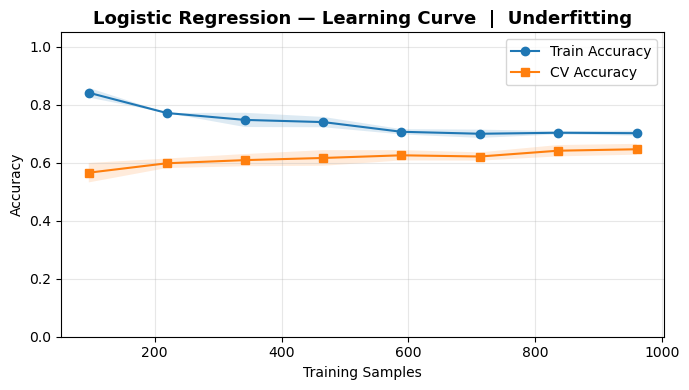


Overfitting Gap (Train − CV): 0.0554


In [192]:
gap_lr = plot_learning_curve(
    LogisticRegression(max_iter=1000),
    X_train_encoded, y_train_encoded,
    title="Logistic Regression — Learning Curve",
    color=PALETTE["Logistic Regression"]
)
print(f"\nOverfitting Gap (Train − CV): {gap_lr:.4f}")


### Catboosting

In [193]:
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()

X_train_cat[cat_features] = X_train_cat[cat_features].astype(str)
X_test_cat[cat_features] = X_test_cat[cat_features].astype(str)


In [194]:
catboost = CatBoostClassifier()

catboost_results, catboost_model = evaluate_model(
    X_tr=X_train_cat,
    X_te=X_test_cat,
    y_tr= y_train_encoded,
    y_te= y_test_encoded,
    model= catboost,
    name="Cat Boost Classifier"
)

print("=" * 52)
print("  Cat Boost Classifier — Metrics")
print("=" * 52)
for k, v in catboost_results.items():
    if k != "Model":
        print(f"  {k:<22}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_encoded, catboost_model.predict(X_test_cat),
                             target_names=CLASS_NAMES.values()))

Learning rate set to 0.079866
0:	learn: 1.0635880	total: 1.61ms	remaining: 1.61s
1:	learn: 1.0238517	total: 4.95ms	remaining: 2.47s
2:	learn: 0.9905009	total: 9.33ms	remaining: 3.1s
3:	learn: 0.9611298	total: 13.8ms	remaining: 3.44s
4:	learn: 0.9400100	total: 18ms	remaining: 3.59s
5:	learn: 0.9177933	total: 21.2ms	remaining: 3.52s
6:	learn: 0.9020935	total: 23.4ms	remaining: 3.33s
7:	learn: 0.8823084	total: 25.2ms	remaining: 3.13s
8:	learn: 0.8665737	total: 26.6ms	remaining: 2.93s
9:	learn: 0.8553266	total: 30.7ms	remaining: 3.04s
10:	learn: 0.8416438	total: 35.9ms	remaining: 3.23s
11:	learn: 0.8292149	total: 41.1ms	remaining: 3.38s
12:	learn: 0.8190105	total: 44.6ms	remaining: 3.38s
13:	learn: 0.8117344	total: 48ms	remaining: 3.38s
14:	learn: 0.8057680	total: 50.9ms	remaining: 3.34s
15:	learn: 0.7952694	total: 54.8ms	remaining: 3.37s
16:	learn: 0.7883552	total: 60.1ms	remaining: 3.47s
17:	learn: 0.7857033	total: 63ms	remaining: 3.44s
18:	learn: 0.7782290	total: 67.1ms	remaining: 3.46s

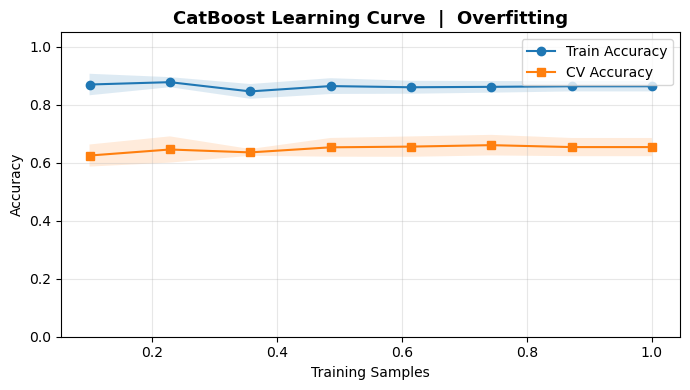


Overfitting Gap (Train − CV): 0.0554


In [195]:
plot_learning_curve(
    estimator=catboost_model,
    X=X_train_cat,
    y=y_train_encoded,
    title="CatBoost Learning Curve",
    cat_features=cat_features
)
print(f"\nOverfitting Gap (Train − CV): {gap_lr:.4f}")


In [ ]:

model = catboost_model

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_cat)

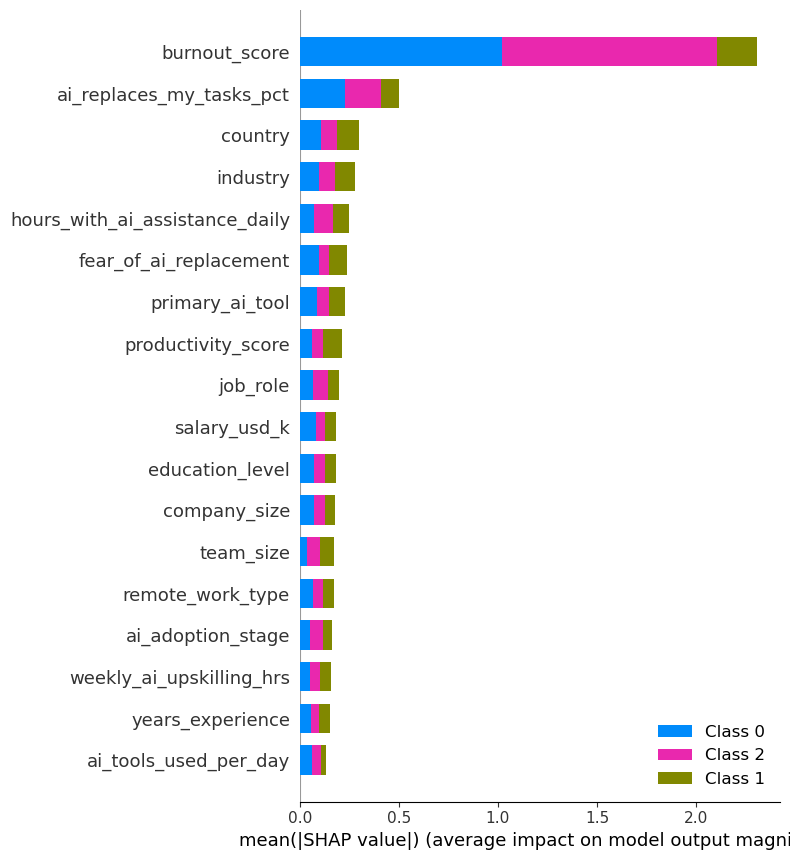

In [197]:
shap.summary_plot(shap_values, X_test_cat, plot_type="bar")